In [1]:
import torch
import numpy as np
import splinepy as sp
import matplotlib.pyplot as plt

import deep_sdf.workspace as ws
import deep_sdf.utils
from sdf_sampler.plotting import scatter_contour_at_origin
import os
os.chdir("/home/michael.kofler/DeepSDF")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device = torch.device("cpu")

experiment_directory = "./experiments/round_cross_big_network"
checkpoint = "1000"

params = {'text.usetex': True}
plt.rcParams.update(params)

latent = ws.load_latent_vectors(experiment_directory, checkpoint).to("cpu").numpy()
decoder = ws.load_trained_model(experiment_directory, checkpoint).to(device)
decoder.eval()
graded = True

In [2]:
n_points = 5
control_points = np.linspace(0.25, 1, n_points).reshape(-1,1)

[-1.  -1.  -0.5  0.   0.5  1.   1. ]


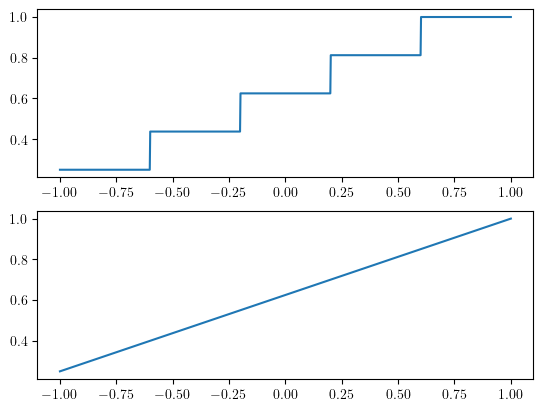

In [3]:
knot_vec_const = np.linspace(-1,1,n_points+1)
discrete_interpolation = sp.BSpline(
    degrees=[0, 0, 0],
    knot_vectors=[knot_vec_const,
                  [-1,1],
                  [-1,1]],
    control_points=control_points,
)
lin = np.linspace(-1,1,n_points)
knot_vec_interpolate = np.concatenate(([-1,], lin, [1,]))
print(knot_vec_interpolate)
continuos_interpolation = sp.BSpline(
    degrees=[1, 0, 0],
    knot_vectors=[knot_vec_interpolate,
                  [-1,1],
                  [-1,1]],
    control_points=control_points,
)
x = np.linspace(-1, 1, 1000).reshape(-1,1)
y = np.zeros_like(x)
z = np.zeros_like(x)
fig, ax = plt.subplots(2,1)
ax[0].plot(x, discrete_interpolation.evaluate(np.hstack([x,y,z])))
ax[1].plot(x, continuos_interpolation.evaluate(np.hstack([x,y,z])))

In [4]:
def transform(x, t):
    p = 2/t
    return (2/p)*torch.abs((x-t%2) % (p*2) - p) -1 

def sdf_struct(queries, latent_vec_interpolation, tiling=[5, 1, 1]):
    queries = torch.tensor(queries, dtype=torch.float32).to(device)
    tx, ty, tz = tiling[0], tiling[1], tiling[2]
    samples = torch.zeros(queries.shape[0], 3)
    samples[:, 0] = transform(queries[:, 0], tx)
    samples[:, 1] = transform(queries[:, 1], ty)
    samples[:, 2] = transform(queries[:, 2], tz)
    lat_vec_red = torch.tensor(latent_vec_interpolation.evaluate(queries.cpu().numpy()), dtype=torch.float32)
    queries = torch.hstack([torch.tensor(lat_vec_red).to(torch.float32).to(device), samples])

    return deep_sdf.utils.decode_sdf(decoder, None, queries).squeeze(1).detach().cpu().numpy()

/tmp/ipykernel_1881118/885622797.py:13: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  queries = torch.hstack([torch.tensor(lat_vec_red).to(torch.float32).to(device), samples])


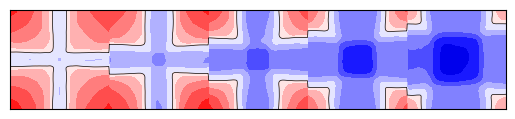

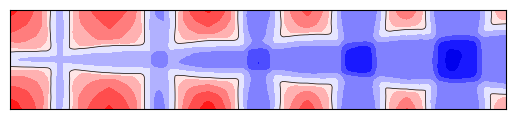

In [5]:
scatter_contour_at_origin(lambda queries: sdf_struct(queries, discrete_interpolation), flip_axes=True, res=1000, scale=1/n_points)
scatter_contour_at_origin(lambda queries: sdf_struct(queries, continuos_interpolation), flip_axes=True, res=1000, scale=1/n_points)

/tmp/ipykernel_1881118/885622797.py:13: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  queries = torch.hstack([torch.tensor(lat_vec_red).to(torch.float32).to(device), samples])
/tmp/ipykernel_1881118/885622797.py:13: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  queries = torch.hstack([torch.tensor(lat_vec_red).to(torch.float32).to(device), samples])


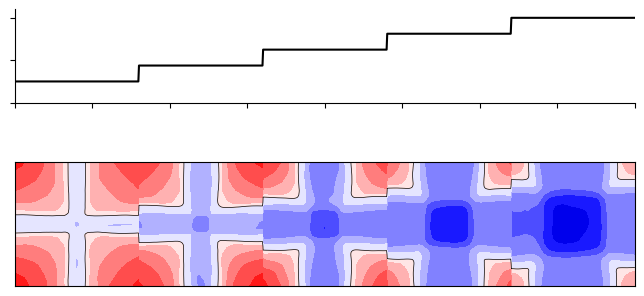

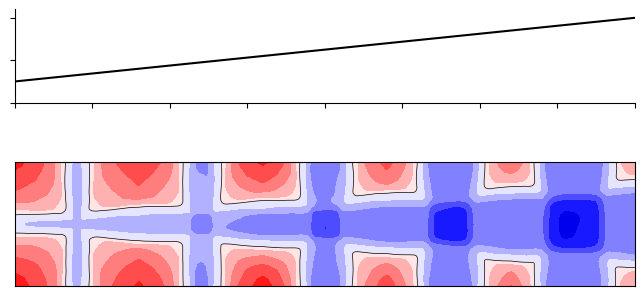

In [6]:
fig, ax = plt.subplots(2,1,gridspec_kw={'height_ratios': [1,2]}, figsize=(8,4))
ax[0].plot(x, discrete_interpolation.evaluate(np.hstack([x,y,z])),c="black")
ax[0].set_xlim([-1,1])
ax[0].set_ylim([0,1.1])
ax[0].spines[['right', 'top']].set_visible(False)
ax[0].set_xticklabels([])
ax[0].set_yticklabels([])
scatter_contour_at_origin(lambda queries: sdf_struct(queries, discrete_interpolation), flip_axes=True, res=1000, scale=1/n_points, custom_axis=ax[1])
plt.savefig("evaluation_scripts/IGA2024/plots/discrete_struct.png", dpi=600, bbox_inches="tight")
fig, ax = plt.subplots(2,1,gridspec_kw={'height_ratios': [1,2]}, figsize=(8,4))
ax[0].plot(x, continuos_interpolation.evaluate(np.hstack([x,y,z])),c="black")
ax[0].set_xlim([-1,1])
ax[0].set_ylim([0,1.1])
ax[0].spines[['right', 'top']].set_visible(False)
ax[0].set_xticklabels([])
ax[0].set_yticklabels([])

scatter_contour_at_origin(lambda queries: sdf_struct(queries, continuos_interpolation), flip_axes=True, res=1000, scale=1/n_points, custom_axis=ax[1])
# def sdf_struct_whole(queries, latent_vec_interpolation):
#     queries = torch.tensor(queries, dtype=torch.float32).to(device)
#     tx, ty, tz = 
#     samples = torch.zeros(queries.shape[0], 3)
#     samples[:, 0] = transform(queries[:, 0], tx)
#     samples[:, 1] = transform(queries[:, 1], ty)
#     samples[:, 2] = transform(queries[:, 2], tz)
#     lat_vec_red = torch.tensor(latent_vec_interpolation.evaluate(queries.cpu().numpy()), dtype=torch.float32)
#     queries = torch.hstack([torch.tensor(lat_vec_red).to(torch.float32).to(device), samples])

#     return deep_sdf.utils.decode_sdf(decoder, None, queries).squeeze(1).detach().cpu().numpy()plt.savefig("evaluation_scripts/IGA2024/plots/interpolated_struct.png", dpi=600, bbox_inches="tight")

/tmp/ipykernel_1881118/885622797.py:13: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  queries = torch.hstack([torch.tensor(lat_vec_red).to(torch.float32).to(device), samples])


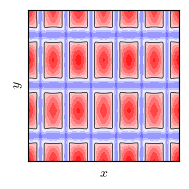

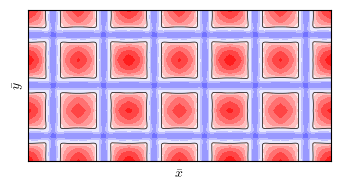

In [11]:
fig, ax = plt.subplots(1, 1, figsize=(5/2.54, 5/2.54))
continuos_interpolation.control_points = np.zeros_like(continuos_interpolation.control_points) + 0.45
scatter_contour_at_origin(lambda queries: sdf_struct(queries, continuos_interpolation, tiling=tiling), flip_axes=True, res=1000, scale=1, custom_axis=ax)
tiling = [6,3,1]
ax.set_xlabel(r"$x$")
ax.set_ylabel(r"$y$")
plt.savefig("evaluation_scripts/IGA2024/plots/struct_before_FFD.png", dpi=600, bbox_inches="tight")

fig, ax = plt.subplots(1, 1, figsize=(5/2.54*10/4, 5/2.54))
scatter_contour_at_origin(lambda queries: sdf_struct(queries, continuos_interpolation, tiling=tiling), flip_axes=True, res=1000, scale=tiling[1]/tiling[0], custom_axis=ax)

ax.set_xlabel(r"$\bar{x}$")
ax.set_ylabel(r"$\bar{y}$")
plt.savefig("evaluation_scripts/IGA2024/plots/struct_after_FFD.png", dpi=600, bbox_inches="tight")